In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family']

mall = pd.read_csv('../datasets/unsupervised/Mall_Customers.csv')
mall.describe()


,CustomerID,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


41.5 78.0
-13.25 132.75
정상범위:-13~133 / 이상치2명


C:\Users\301-21\AppData\Local\Temp\ipykernel_4176\2298306691.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.figure(figsize=(8,3)); plt.boxplot(x, vert=False)


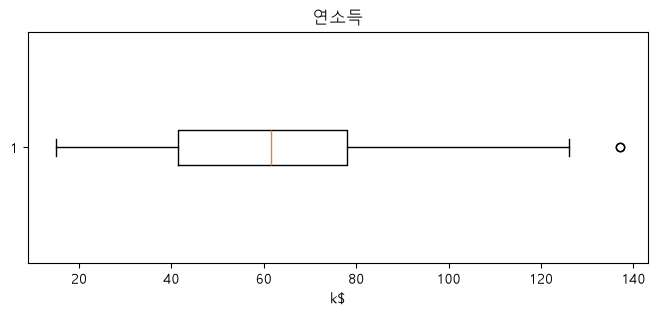

In [7]:
# 이상치 확인: IQR = Q3(75%)-Q1(25%)

x = mall['Annual Income']
Q1, Q3 = x.quantile(0.25), x.quantile(0.75)
print(Q1, Q3)
IQR = Q3 - Q1
low, high = Q1 - 1.5 *IQR, Q3 + 1.5*IQR
print(low, high)
outliers = mall[(x<low) | (x>high)]
print(f'정상범위:{low:.0f}~{high:.0f} / 이상치{len(outliers)}명')

plt.figure(figsize=(8,3)); plt.boxplot(x, vert=False)
plt.title('연소득'); plt.xlabel('k$'); plt.show()

In [13]:
#z-score(평균, 표준편차 이용)
z = (x-x.mean())/x.std()  #평균에서 표준편차의 몇 배 떨어졌는지
#보통 z > 3 (평균에서 표준편차 3배 이상이면 이상치)
mall['income_z'] = z
print('z>3 인 이상치 수', (z.abs()>3).sum())
#r: 없네;; 그럼 좀더 확대

#z- 점수 상위 5명
print('z- 점수 상위 5명')
print(mall.loc[z.abs().sort_values(ascending=False).index[:5],['Annual Income']])

z>3 인 이상치 수 0
z- 점수 상위 5명
     Annual Income
199            137
198            137
197            126
196            126
195            120


In [21]:
df= pd.read_csv('../datasets/housing/housing.csv')
#캘리포니아 주택 데이터셋
#IQR 이용하여 이상치 개수 구하시오
#1. 주택 중간가격(median_house_value)칼럼의 이상치
#2. 해당 이상치 데이터를 제거(정상 데이터만 남김) 후 정상 데이터의 표준편차(std)를 소수점 셋째 자리에서 버림
df['median_house_value'].describe()
#이상치 제거 전 = 전체 건수 20,640, std=115395.615874 (소수점 셋째에서 버리면 std=115,395.615)

# 1. median_house_value의 IQR 계산
q1 = df['median_house_value'].quantile(0.25)
q3 = df['median_house_value'].quantile(0.75)
iqr = q3 - q1 ; lower = q1 - 1.5 * iqr; upper = q3 + 1.5 * iqr
print('Q1:', q1); print('Q3:', q3); print('IQR:', iqr); print('하한:', lower); print('상한:', upper)

outlier = ((df['median_house_value'] < lower) | (df['median_house_value'] > upper))
print('이상치 개수:', outlier.sum()) 
#여기의 outlier는 이상치 데이터 자체가 아니라, 각 행이 이상치인지 나타내는 Boolean Series
#파이썬에서 True = 1, False = 0처럼 계산되므로, 이상치 개수 = outlier.sum()
#len()을 쓰고 싶다면 이상치만 필터링 len(df[outlier])

# 2. 이상치 제거
normal = df[~outlier]
# 이상치 제거한 정상 데이터의 표준편차
std = normal['median_house_value'].std()
# 소수점 셋째 자리에서 버림 → 소수점 둘째 자리까지
std_trunc = np.floor(std * 100) / 100
print('이상치 제거한 정상 데이터 표준편차:', std_trunc) #r:  std=95,438.55

Q1: 119600.0
Q3: 264725.0
IQR: 145125.0
하한: -98087.5
상한: 482412.5
이상치 개수: 1071
정상 데이터 표준편차: 95438.55


In [ ]:
nomal_vals = df[(df['median_house_value'] >= lower_b)] & (df['median_house_value']<=upper_b)]['median_house_value']
print('이상치 제거 후 정상 데이터:', len(normal_vals))
std_val = normal_vals.std()
result2 = np.trunc(std_val *100) /  #trunc은 정수 기준이라 소수점 다 버리니까 100곱해준 후 다시 100나눔
print()